# Bays (2014) Figure 3 Equivalence - Attention and Cued Items

**Goal.** Reproduce Bays Fig 3 (cued/uncued error distributions, variance, kurtosis) using a **biologically motivated alternative** to gain modulation: cueing recruits the subpopulation of neurons most informative about the cued location, and that subpopulation does *all* the work — encoding the cued and uncued items alike.

---


1. The cue identifies a location (by convention, location 0).
2. We rank all M neurons by their **sharpness at location 0** — concretely, the variance of their tuning curve f_{n,0}(θ) along the orientation grid. Neurons with sharper (narrower) tuning have larger swings and so larger variance; neurons with broad, flat tuning have small variance.
3. The top **M/l** neurons (where l is the set size) are the *recruited subpopulation* I_c. Every other neuron is silent for the trial — they are not in the picture at all.
4. The recruited neurons compute their pre-DN response normally, multiplying tuning across **all l locations** (cued and uncued):

$$r_n^{\text{pre}}(S, \theta) = \prod_{k \in S} g_{n,k}(\theta_k), \quad n \in I_c$$

5. DN, Poisson noise, and ML decoding all operate on this restricted set.



## GP Framework for Attention & Cued Models

### Imports

Same imports as the original notebook. We reuse `Population` for construction and `ml_decode` / circular statistics from `core.decoder.ml_decoder`. We do **not** use `Population.run_trials` here — that function operates on the full population, and the whole point of this notebook is to restrict to the recruited subset.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
RESULTS_DIR = Path.cwd().parents[1] / 'result_data'
RESULTS_DIR.mkdir(exist_ok=True)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0

from core.population import Population
from core.decoder.ml_decoder import (
    decode as ml_decode,
    circular_error,
    circular_variance_fisher,
    circular_kurtosis_fisher,
)

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [2]:
def vonmises_kde(data, eval_points, kappa):
    '''Circular KDE using von Mises kernels (no boundary artefacts at +/- pi).'''
    data = np.asarray(data); eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm
    return np.exp(logsumexp(log_kernels, axis=1) - np.log(n))

KAPPA_KDE = 10.0


### Configuration

Changes from the previous notebook:

- **Soft gain instead of hard mask.** We compute $r^{\text{pre}}$ over the **full** population of $M$ neurons. Recruitment now means the top $M/l$ sharpest-at-location-0 neurons get their pre-DN drive multiplied by $\alpha$; everyone else is left at $\times 1$. The hard-mask limit corresponds to $\alpha \to \infty$.
- **DN over the full $M$.** The denominator $D = \sigma^2 + \frac{1}{M}\sum_n r^{\text{pre}}_n$ averages over *all* $M$ neurons, not just the recruited subset. The consequence is that, holding $\gamma$ fixed, the post-DN rate per recruited neuron is roughly $l\times$ smaller than in the previous hard-mask version where DN normalised by $M/l$. Equivalently: the total post-DN activity budget is $\gamma M$ distributed across all $M$ neurons, and the recruited subset captures a share of it proportional to $\alpha r^{\text{pre}}_{\text{recruited}} / (\alpha r^{\text{pre}}_{\text{recruited}} + r^{\text{pre}}_{\text{rest}})$. This is a different physical claim from the recruitment-pool-only DN of the previous notebook and is worth keeping in mind when comparing variance magnitudes.
- **`M = 1000`** kept the same so the recruited subset $M/l \in \{500, 250, 125\}$ is substantial.
- **`N_TRIALS`** is the per-condition trial count.
- The Bays parametric values for $\omega$ and $\gamma$ are unchanged so per-neuron activity scale is comparable.
- **`ALPHA`** is the new free parameter — set to a single value here, but the cell is structured so you can sweep it.


In [3]:
M = 1000             # neurons (full pool -- DN normalises over all of them)
N_THETA = 128        # orientation grid resolution
N_TRIALS = 5000      # trials per (set_size, probe condition)
T_D = 0.1
SIGMA_SQ = 1e-6

# Bays (2014) fitted parameters -- omega = lambda^2, so lambda = sqrt(omega)
OMEGA_BAYS = 0.52
GAMMA_BAYS = 119.0
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)
GAMMA = GAMMA_BAYS / M

SET_SIZES = [2, 4, 8]
CUE_RATIO = 3.0      # cued item probed 3x as often as each individual uncued item
SEED = 42

# --- Soft-recruitment gain ---
# alpha > 1: recruited neurons (top M/l sharpest at loc 0) get boosted drive.
# alpha = 1: no attention (sanity check -- cued should ~= uncued).
# alpha -> inf: approaches the hard-mask recruitment limit.
ALPHA = 10.0

print(f'M={M}, N_THETA={N_THETA}, lambda={LAMBDA_BASE:.4f} (omega = lambda^2 = {LAMBDA_BASE**2:.3f})')
print(f'gamma={GAMMA:.4f} Hz/neuron, total gamma*M={GAMMA*M:.1f} Hz')
print(f'alpha={ALPHA} (recruited multiplier; non-recruited stay at x1)')
print(f'Recruitment counts (M/l):')
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    print(f'  l={N}: |I_c| = {M // N} neurons, p_cued = {p_c:.3f}')


M=1000, N_THETA=128, lambda=0.7211 (omega = lambda^2 = 0.520)
gamma=0.1190 Hz/neuron, total gamma*M=119.0 Hz
alpha=10.0 (recruited multiplier; non-recruited stay at x1)
Recruitment counts (M/l):
  l=2: |I_c| = 500 neurons, p_cued = 0.750
  l=4: |I_c| = 250 neurons, p_cued = 0.500
  l=8: |I_c| = 125 neurons, p_cued = 0.300


In [4]:
max_locs = max(SET_SIZES)
pop = Population(
    M=M, n_theta=N_THETA, omega=OMEGA_BAYS,
    tuning_type='gp', n_locations=max_locs, seed=SEED,
    lengthscale_variability=0.5, gain_variability=0.0
)
print(pop)
print(f'f shape: {pop.f.shape}')

# Sanity check: distribution of sharpness scores at location 0
sharp0 = pop.f[:, 0, :].var(axis=1)
print(f'Sharpness at location 0 -- min: {sharp0.min():.4f}, '
      f'median: {np.median(sharp0):.4f}, max: {sharp0.max():.4f}')
print(f'Top/bottom sharpness ratio: {sharp0.max() / max(sharp0.min(), 1e-9):.1f}x')


Population(N=1000, L=8, n_theta=128, tuning='gp', omega=0.52)
f shape: (1000, 8, 128)
Sharpness at location 0 -- min: 0.0196, median: 0.6474, max: 3.9076
Top/bottom sharpness ratio: 199.6x


### Pipeline

Pipeline below. The structure is:

**Outer loop over set sizes l ∈ {2, 4, 8}.** For each l:

1. **Identify the recruited set.** Compute per-neuron sharpness at location 0 as `pop.f[:, 0, :].var(axis=1)`. Sort descending. Take the top `M_recruit = M // l` indices. Build a boolean mask `recruited_mask` of length $M$.

2. **Compute $r^{\text{pre}}$ on the full population** (not just the recruited subset). Shape `(M, N_TRIALS)`.

3. **Apply the soft gain.** `r_pre[recruited_mask] *= ALPHA`. Non-recruited neurons are untouched. This is the only place `ALPHA` enters the model.

4. **DN over all $M$ neurons.** $D = \sigma^2 + M^{-1}\sum_n r^{\text{pre}}_n$, then $r^{\text{post}}_n = \gamma\, r^{\text{pre}}_n / D$. Note that the per-trial max subtraction for numerical stability still cancels exactly in the DN ratio, because $\alpha$ is a per-neuron constant and the max is a per-trial constant — both factor out cleanly.

5. **Poisson spikes** for all $M$ neurons.

6. **ML decode** at the probed location, using the **full population's** tuning curves $\{f_{n,k}(\theta)\}_{n=1}^M$. The decoder sees every neuron's spikes and uses every neuron's tuning — it has no knowledge of which were recruited.

7. **Probe selection.** Cued probes go to location 0 (the location used for sharpness ranking). Uncued probes sample a location uniformly from $\{1, \ldots, l-1\}$ per trial, mirroring the typical-uncued-experience choice from the previous notebook.

8. **Build the "all trials" mixture** with the Bays 3:1 schedule.

Sanity-check intuition for two limits:

- **$\alpha = 1$**: no attention. The recruited mask still exists but does nothing. Cued and uncued errors should be statistically indistinguishable (modulo finite-sample noise from probe-location averaging).
- **$\alpha \gg 1$**: hard-recruitment limit. The denominator becomes dominated by recruited neurons, so DN effectively normalises over the recruited subset, and non-recruited rates are driven toward zero by $r^{\text{post}}_n = \gamma r^{\text{pre}}_n / D \to \gamma r^{\text{pre}}_n / (\alpha r^{\text{pre}}_{\text{recruited}}/M)\cdot l/M_{\text{rec}}$ etc. Spike counts from non-recruited neurons fall to zero. We should approach the previous notebook's behaviour.


In [5]:
t0 = time.time()
summary = {}

for N in SET_SIZES:
    M_recruit = M // N
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)

    # ---- 1. Identify the recruited set (boolean mask over the full population) ----
    sharpness = pop.f[:, 0, :].var(axis=1)                  # (M,)
    recruited_idx = np.argsort(-sharpness)[:M_recruit]      # (M_recruit,)
    recruited_mask = np.zeros(M, dtype=bool)
    recruited_mask[recruited_idx] = True

    # ---- 2. Encode + scale + decode pipeline, parametrised by probe location ----
    def run_one(probe_cued, rng):
        # Sample theta indices for each location (cued at index 0)
        theta_idxs = rng.randint(N_THETA, size=(N_TRIALS, N))

        # 2a. Vectorised pre-DN log-drive on the FULL population
        log_r_pre = np.zeros((M, N_TRIALS))
        for k in range(N):
            log_r_pre += pop.f[:, k, theta_idxs[:, k]]

        # 2b. Numerical stability -- per-trial max subtraction (cancels in DN ratio)
        log_r_pre -= log_r_pre.max(axis=0, keepdims=True)
        r_pre = np.exp(log_r_pre)                            # (M, N_TRIALS)

        # 2c. Soft gain: boost recruited rows by ALPHA; non-recruited stay at x1
        r_pre[recruited_mask] *= ALPHA

        # 2d. DN over the FULL population
        D = SIGMA_SQ + r_pre.mean(axis=0)
        r_post = GAMMA * r_pre / D[np.newaxis, :]

        # 2e. Poisson spikes for ALL M neurons
        counts = rng.poisson(r_post * T_D)                   # (M, N_TRIALS)

        # 2f. ML decode at the probed location, using ALL neurons' tuning
        if probe_cued or N <= 1:
            probed_loc_per_trial = np.zeros(N_TRIALS, dtype=int)
        else:
            probed_loc_per_trial = rng.randint(1, N, size=N_TRIALS)

        f_per_loc = [pop.f[:, k, :] for k in range(N)]

        theta_hat = np.empty(N_TRIALS)
        for loc in np.unique(probed_loc_per_trial):
            mask = probed_loc_per_trial == loc
            th, _ = ml_decode(counts[:, mask].T, f_per_loc, pop.theta_grid,
                              cued_location=int(loc))
            theta_hat[mask] = th

        theta_true = pop.theta_grid[
            theta_idxs[np.arange(N_TRIALS), probed_loc_per_trial]
        ]
        return circular_error(theta_true, theta_hat)

    rng_c = np.random.RandomState(SEED + N * 1000)
    rng_u = np.random.RandomState(SEED + N * 1000 + 500_000)
    ec = run_one(probe_cued=True,  rng=rng_c)
    eu = run_one(probe_cued=False, rng=rng_u)

    # ---- 3. Build the experimental "all trials" mixture ----
    nc = int(round(p_c * N_TRIALS))
    ea = np.concatenate([ec[:nc], eu[:N_TRIALS - nc]])

    summary[N] = {
        'p_c': p_c,
        'M_recruit': M_recruit,
        'err_all': ea, 'err_cued': ec, 'err_uncued': eu,
        'va': circular_variance_fisher(ea),
        'vc': circular_variance_fisher(ec),
        'vu': circular_variance_fisher(eu),
        'ka': circular_kurtosis_fisher(ea),
        'kc': circular_kurtosis_fisher(ec),
        'ku': circular_kurtosis_fisher(eu),
    }
    s = summary[N]
    print(f"  l={N} (|I_c|={s['M_recruit']}, p_cued={p_c:.2f}, alpha={ALPHA}):  "
          f"sigma2_c={s['vc']:.3f} sigma2_u={s['vu']:.3f}  "
          f"k_c={s['kc']:.2f} k_u={s['ku']:.2f}")

print(f'\nTotal time: {time.time()-t0:.1f}s')


  l=2 (|I_c|=500, p_cued=0.75, alpha=10.0):  sigma2_c=0.143 sigma2_u=0.240  k_c=21.95 k_u=13.11
  l=4 (|I_c|=250, p_cued=0.50, alpha=10.0):  sigma2_c=0.213 sigma2_u=0.521  k_c=12.44 k_u=5.41
  l=8 (|I_c|=125, p_cued=0.30, alpha=10.0):  sigma2_c=0.530 sigma2_u=0.835  k_c=5.14 k_u=2.91

Total time: 1.4s


### Figures - Plotting 

The layout matches the previous notebook's Figure 3 exactly so the visual comparison is direct. Panel d is the only one that has changed in *content*: it no longer shows optimal α* per set size (there is no α to optimise), but the recruitment count |I_c| = M/l per set size — the analog of "what attention is allocating" in the recruitment model.

- **a:** error distributions, 3 rows (all / cued / uncued) × 3 cols (l = 2, 4, 8). Cued (red) should peak higher and have shorter tails than uncued (green) at every set size.
- **b:** variance vs set size on log₂ × log₂ axes. Both cued and uncued should grow with l; cued should sit below uncued throughout.
- **c:** kurtosis vs set size. Positive everywhere — deviations from circular normal are the signature of a low-SNR Poisson regime.
- **d:** recruitment count |I_c| per set size, with values labelled. As l grows, fewer neurons are recruited — this is the new "attentional budget" view.


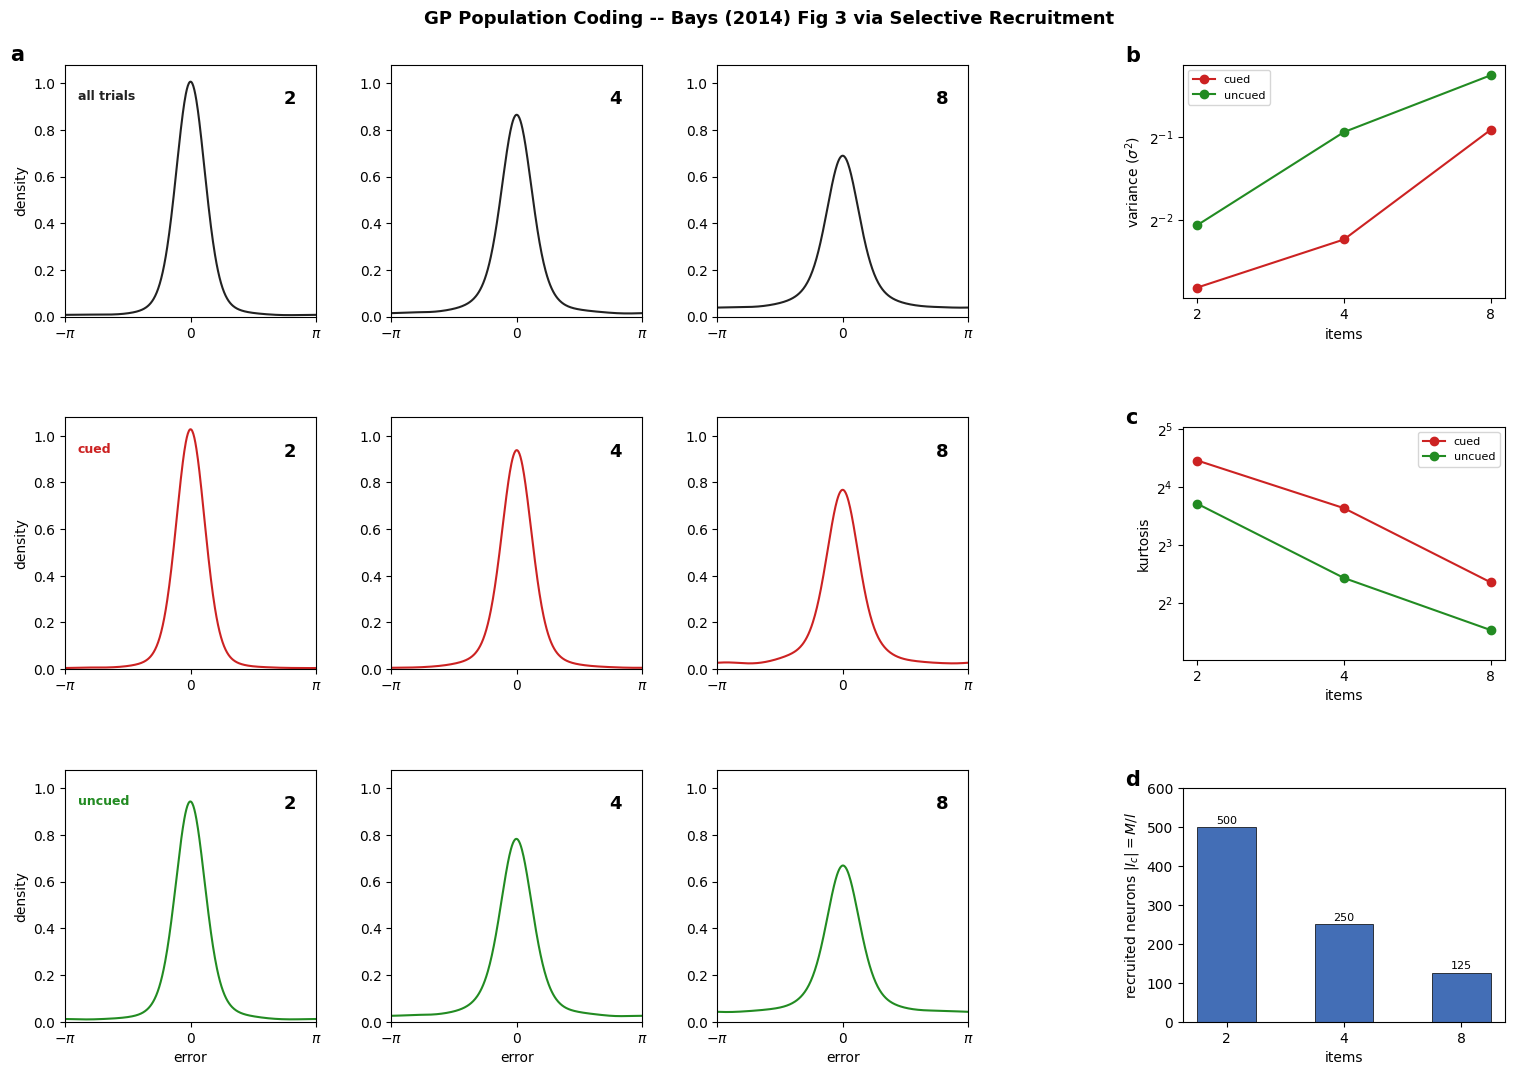

In [6]:
RED, GREEN, BLACK, BLUE = '#CC2222', '#228B22', '#222222', '#2255AA'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

# Shared y-max for panel a
y_max = 0
for N in SET_SIZES:
    for k in ('err_all', 'err_cued', 'err_uncued'):
        d = vonmises_kde(summary[N][k], theta_smooth, KAPPA_KDE)
        y_max = max(y_max, d.max())
y_max *= 1.05

fig = plt.figure(figsize=(16, 11))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.8, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.06, top=0.93)
gs_a   = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
            subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bcd = gridspec.GridSpecFromSubplotSpec(3, 1,
            subplot_spec=outer[1], hspace=0.55)

# ---------- Panel a ----------
row_configs = [('err_all',    BLACK, 'all trials'),
               ('err_cued',   RED,   'cued'),
               ('err_uncued', GREEN, 'uncued')]
for row, (key, color, label) in enumerate(row_configs):
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        d = vonmises_kde(summary[N][key], theta_smooth, KAPPA_KDE)
        ax.plot(theta_smooth, d, color=color, lw=1.5)
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, y_max)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if row == 2: ax.set_xlabel('error')
        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='right')
        if col == 0:
            ax.set_ylabel('density')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', va='top', color=color)

fig.axes[0].text(-0.22, 1.08, r'$\mathbf{a}$', transform=fig.axes[0].transAxes,
                 fontsize=15, fontweight='bold', va='top')

ns = np.array(SET_SIZES, dtype=float)

# ---------- Panel b: variance ----------
ax_b = fig.add_subplot(gs_bcd[0])
vc = [summary[N]['vc'] for N in SET_SIZES]
vu = [summary[N]['vu'] for N in SET_SIZES]
ax_b.plot(ns, vc, 'o-', color=RED,   lw=1.5, ms=6, label='cued')
ax_b.plot(ns, vu, 'o-', color=GREEN, lw=1.5, ms=6, label='uncued')
ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.legend(fontsize=8, loc='upper left')
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel c: kurtosis ----------
ax_c = fig.add_subplot(gs_bcd[1])
kc = [summary[N]['kc'] for N in SET_SIZES]
ku = [summary[N]['ku'] for N in SET_SIZES]
ax_c.plot(ns, kc, 'o-', color=RED,   lw=1.5, ms=6, label='cued')
ax_c.plot(ns, ku, 'o-', color=GREEN, lw=1.5, ms=6, label='uncued')
ax_c.set_xscale('log', base=2); ax_c.set_yscale('log', base=2)
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])
all_k = [k for k in (kc + ku) if k > 0]
if all_k:
    ax_c.set_ylim(min(all_k) * 0.7, max(all_k) * 1.5)
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.legend(fontsize=8, loc='upper right')
ax_c.text(-0.18, 1.08, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel d: recruitment count ----------
ax_d = fig.add_subplot(gs_bcd[2])
recruit_counts = [summary[N]['M_recruit'] for N in SET_SIZES]
bar_x = np.arange(len(SET_SIZES))
bars = ax_d.bar(bar_x, recruit_counts, 0.5,
                color=BLUE, alpha=0.85, edgecolor='k', lw=0.6)
for x, c in zip(bar_x, recruit_counts):
    ax_d.text(x, c + max(recruit_counts) * 0.02, f'{c}',
              ha='center', fontsize=8)
ax_d.set_xticks(bar_x); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items')
ax_d.set_ylabel(r'recruited neurons $|I_c| = M/l$')
ax_d.set_ylim(0, max(recruit_counts) * 1.2)
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding -- Bays (2014) Fig 3 via Selective Recruitment',
             fontsize=13, fontweight='bold')
plt.savefig('bays_fig3_recruitment.png', dpi=150, bbox_inches='tight')
plt.show()


## Bays (2014) Original Model — Comparison Baseline

The GP section above implements the **biologically motivated alternative** to gain modulation: selective recruitment of sharp-tuned neurons at the cued location. To validate that approach we need a like-for-like comparison against the original Bays (2014) parametric model, where the cued/uncued asymmetry is produced by an attentional gain factor $\alpha_{\text{cued}}$ on the input drive to neurons encoding the cued item.

Same divisive-normalisation pipeline, same Poisson noise, same ML decoder, same circular statistics. The only difference is **how the cued/uncued asymmetry arises**:

- **Bays (this section):** every active location has identical von Mises tuning $f = \exp(\omega^{-1}(\cos(\phi-\theta)-1))$; the cued location gets $\alpha_{\text{cued}} > 1$ in Eq. 2, all others get $\alpha = 1$. Asymmetry = differential input drive.
- **GP (section above):** identical $\alpha$ across locations, but only the sharpest-at-cued-location $M/l$ neurons participate. Asymmetry = differential neuron recruitment.

The Bays parameters $\omega = 0.49$, $\gamma = 81$ Hz are the ML estimates from his Experiment 2 paper (Materials and Methods, p. 3636); $\alpha_{\text{cued}}$ values are taken from his Fig 3d (the empirical ML estimates per set size, roughly $\{1.5, 2.3, 3.3\}$ for $l \in \{2,4,8\}$).


In [7]:
# Standalone Bays (2014) — three audit fixes applied vs. naive port:
#   1. DN denominator = sum exp(f) only.  No semi-saturation sigma^2 added.
#   2. True orientations are sampled continuously from [-pi, pi).
#   3. argmax with random tie-breaking, per Bays's explicit specification.

def bays_build_population(M_bays):
    phi = np.linspace(-np.pi, np.pi, M_bays, endpoint=False)
    return phi


def bays_driving_input(phi, theta_per_loc, omega):
    # Eq. 1:  f_i(theta_k) = exp( (1/omega) * (cos(phi_i - theta_k) - 1) )
    diff = phi[None, :] - np.asarray(theta_per_loc)[:, None]      # (l, M)
    return np.exp((1.0 / omega) * (np.cos(diff) - 1.0))


def bays_divisive_normalisation(f, gamma_total):
    # Eq. 2/3 with alpha_j = 1 everywhere active.
    denom = f.sum()
    return gamma_total * f / denom


def bays_poisson_spikes(rates, T_d, rng):
    return rng.poisson(rates * T_d)


def bays_ml_decode(counts_probed, phi, n_grid=1000, rng=None):
    # Eq. 8 with random tie-breaking.
    if rng is None:
        rng = np.random.RandomState()
    theta_eval = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    objective  = counts_probed @ np.cos(phi[:, None] - theta_eval[None, :])
    max_val = objective.max()
    tied    = np.flatnonzero(objective >= max_val - 1e-12)
    return theta_eval[rng.choice(tied)]


def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    M_bays=100, rng=None, n_decode_grid=1000):
    # Vectorised Exp 1 trial runner. Uniform probe, uniform alpha.
    if rng is None:
        rng = np.random.RandomState()

    l   = set_size
    phi = bays_build_population(M_bays)

    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))
    cued       = rng.randint(l, size=n_trials)

    diff = phi[None, None, :] - theta_true[:, :, None]
    f    = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))

    denom = f.sum(axis=(1, 2))
    rates = gamma_total * f / denom[:, None, None]

    counts        = rng.poisson(rates * T_d)
    counts_probed = counts[np.arange(n_trials), cued, :]

    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid   = np.cos(phi[:, None] - theta_eval[None, :])
    objective  = counts_probed @ cos_grid

    max_vals  = objective.max(axis=1, keepdims=True)
    tied_mask = objective >= max_vals - 1e-12
    keys      = rng.random(objective.shape) * tied_mask
    chosen    = keys.argmax(axis=1)
    theta_hat = theta_eval[chosen]

    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


print('Defined: bays_build_population, bays_driving_input,')
print('         bays_divisive_normalisation, bays_poisson_spikes,')
print('         bays_ml_decode, bays_run_trials  (Experiment 1)')


Defined: bays_build_population, bays_driving_input,
         bays_divisive_normalisation, bays_poisson_spikes,
         bays_ml_decode, bays_run_trials  (Experiment 1)


### Cued/Uncued Runner and Two-Tier Simulation

`bays_run_trials_cued` is the Experiment 2 extension. Compared to `bays_run_trials` above, four things change:

1. **Per-location alpha vector.** Location 0 (by convention) gets $\alpha_{\text{cued}}$; all other active locations get $\alpha = 1$.
2. **Weighted DN denominator.** $\sum_{m,n} \alpha_n f_{mn}$ instead of $\sum f_{mn}$ — so boosting the cued item steals normalised activity from the uncued items. *This is the entire mechanism producing the asymmetry.*
3. **Biased probe selection.** Probe lands on the cued item with probability $c/(c+l-1)$, where $c = 3$ is the cued/uncued test ratio (Bays Materials and Methods).
4. **Returns a `probe_is_cued` mask** so we can split errors after the fact.

**Two-tier simulation strategy** (the reason this cell looks the way it does):

Bays's Fig 3 has two distinct uncertainty representations:
- **Solid dots with vertical error bars** in panels b/c → point estimate ± SEM across subjects (n=7).
- **Dashed lines flanking each solid line** in panels b/c → the model's predicted ±1 SEM band.

To reproduce both without sacrificing the smoothness of the panel-a KDEs, we run two independent simulations per set size:

- **Tier 1 (display pool):** one big simulation of `N_TRIALS_DISPLAY = 50_000` trials, used only to compute the KDE curves in panel a. With tens of thousands of samples the von-Mises KDE looks smooth at any reasonable bandwidth.
- **Tier 2 (Bays-realistic batches):** `N_BATCHES = 7` independent simulations of `N_TRIALS_PER_BATCH = 320` trials each — matching Bays's n=7 subjects with 320 trials per subject per set size. Per-batch variance/kurtosis estimates fluctuate meaningfully at this trial count, and their across-batch SEM gives Bays-realistic error bars / dashed bands.


In [8]:
# ---------------------------------------------------------------------------
# Cued-trial runner.  Differences from bays_run_trials (Exp 1):
#   (i)   one location (index 0) gets alpha_cued; others get alpha=1.
#   (ii)  DN denominator sums alpha_n * f_mn over (l, M).
#   (iii) probe is cued with prob c/(c + l - 1),  c = 3.
#   (iv)  returns errors AND a boolean mask marking cued-probe trials.
# ---------------------------------------------------------------------------
def bays_run_trials_cued(n_trials, set_size, omega, gamma_total, T_d,
                         alpha_cued, cued_probe_ratio=3.0,
                         M_bays=100, rng=None, n_decode_grid=1000):
    if rng is None:
        rng = np.random.RandomState()

    l   = set_size
    phi = bays_build_population(M_bays)

    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))

    alphas       = np.ones((n_trials, l))
    alphas[:, 0] = alpha_cued

    p_cued        = cued_probe_ratio / (cued_probe_ratio + (l - 1))
    probe_is_cued = rng.random(n_trials) < p_cued
    probed = np.empty(n_trials, dtype=int)
    probed[probe_is_cued] = 0
    n_unc = (~probe_is_cued).sum()
    if n_unc > 0:
        probed[~probe_is_cued] = rng.randint(1, l, size=n_unc)

    diff = phi[None, None, :] - theta_true[:, :, None]
    f    = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))

    f_w   = alphas[:, :, None] * f
    denom = f_w.sum(axis=(1, 2))
    rates = gamma_total * f_w / denom[:, None, None]

    counts        = rng.poisson(rates * T_d)
    counts_probed = counts[np.arange(n_trials), probed, :]

    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid   = np.cos(phi[:, None] - theta_eval[None, :])
    objective  = counts_probed @ cos_grid
    max_vals   = objective.max(axis=1, keepdims=True)
    tied_mask  = objective >= max_vals - 1e-12
    keys       = rng.random(objective.shape) * tied_mask
    theta_hat  = theta_eval[keys.argmax(axis=1)]

    d      = theta_hat - theta_true[np.arange(n_trials), probed]
    errors = (d + np.pi) % (2.0 * np.pi) - np.pi
    return errors, probe_is_cued


# Circular statistics (Fisher 1995) — identical to the GP framework's
# circular_variance_fisher / circular_kurtosis_fisher, kept local for clarity.
def _circ_var(errors):
    m1 = np.mean(np.exp(1j * errors))
    return -2.0 * np.log(np.abs(m1))

def _circ_kurt(errors):
    m1   = np.mean(np.exp(1j * errors))
    m2   = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    num  = np.abs(m2) * np.cos(np.angle(m2) - 2 * np.angle(m1)) - rho1**4
    den  = (1.0 - rho1)**2
    return num / den

# ---------------------------------------------------------------------------
# Parameters: Bays (2014) Experiment 2 fitted values.
#   omega = 0.49,  gamma = 81 Hz,  T_d = 100 ms  (Bays p. 3636)
#   alpha_cued per set size from Fig 3d (ML estimates, white bars).
# ---------------------------------------------------------------------------
OMEGA_B      = 0.49
GAMMA_B      = 81.0
T_D_B        = 0.100
M_BAYS       = 100
ALPHA_CUED   = {2: 1.5, 4: 2.3, 8: 3.3}

# Two-tier simulation -----------------------------------------------------
# Tier 1: big display pool for smooth panel-a KDEs.
# Tier 2: 7 Bays-realistic batches for panel b/c SEM bands.
N_TRIALS_DISPLAY    = 50_000
N_BATCHES           = 7
N_TRIALS_PER_BATCH  = 320

rng_bays      = np.random.RandomState(42)
summary_bays  = {}

for N in SET_SIZES:
    # ---- Tier 1: big pool for KDE display only ----
    err_big, is_c_big = bays_run_trials_cued(
        n_trials=N_TRIALS_DISPLAY, set_size=N,
        omega=OMEGA_B, gamma_total=GAMMA_B, T_d=T_D_B,
        alpha_cued=ALPHA_CUED[N], cued_probe_ratio=CUE_RATIO,
        M_bays=M_BAYS, rng=rng_bays,
    )

    # ---- Tier 2: small batches for SEM estimation ----
    vc_batch, vu_batch, kc_batch, ku_batch = [], [], [], []
    for b in range(N_BATCHES):
        err_b, is_c_b = bays_run_trials_cued(
            n_trials=N_TRIALS_PER_BATCH, set_size=N,
            omega=OMEGA_B, gamma_total=GAMMA_B, T_d=T_D_B,
            alpha_cued=ALPHA_CUED[N], cued_probe_ratio=CUE_RATIO,
            M_bays=M_BAYS, rng=rng_bays,
        )
        err_c_b, err_u_b = err_b[is_c_b], err_b[~is_c_b]
        # Guard against degenerate batches (kurtosis on n<5 is meaningless).
        if len(err_c_b) > 5 and len(err_u_b) > 5:
            vc_batch.append(_circ_var(err_c_b))
            vu_batch.append(_circ_var(err_u_b))
            kc_batch.append(_circ_kurt(err_c_b))
            ku_batch.append(_circ_kurt(err_u_b))

    vc_batch = np.array(vc_batch); vu_batch = np.array(vu_batch)
    kc_batch = np.array(kc_batch); ku_batch = np.array(ku_batch)
    sem = lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

    summary_bays[N] = dict(
        # Panel a: errors from the big pool (smooth KDEs).
        err_all   = err_big,
        err_cued  = err_big[is_c_big],
        err_uncued= err_big[~is_c_big],
        # Panels b, c: point estimates from big pool (most reliable),
        # SEMs from small batches (Bays-realistic noise level).
        vc = _circ_var (err_big[is_c_big]),
        vu = _circ_var (err_big[~is_c_big]),
        kc = _circ_kurt(err_big[is_c_big]),
        ku = _circ_kurt(err_big[~is_c_big]),
        vc_sem = sem(vc_batch), vu_sem = sem(vu_batch),
        kc_sem = sem(kc_batch), ku_sem = sem(ku_batch),
        alpha_cued = ALPHA_CUED[N],
        n_cued     = int(is_c_big.sum()),
        n_uncued   = int((~is_c_big).sum()),
    )

print(f"{'l':>2} {'a_c':>5} {'n_c':>6} {'n_u':>6} "
      f"{'var_c':>14} {'var_u':>14} {'kurt_c':>14} {'kurt_u':>14}")
for N in SET_SIZES:
    s = summary_bays[N]
    print(f"{N:>2} {s['alpha_cued']:>5.2f} {s['n_cued']:>6d} {s['n_uncued']:>6d} "
          f"{s['vc']:>7.3f}±{s['vc_sem']:.3f} "
          f"{s['vu']:>7.3f}±{s['vu_sem']:.3f} "
          f"{s['kc']:>7.3f}±{s['kc_sem']:.3f} "
          f"{s['ku']:>7.3f}±{s['ku_sem']:.3f}")


 l   a_c    n_c    n_u          var_c          var_u         kurt_c         kurt_u
 2  1.50  37394  12606   0.213±0.012   0.390±0.034   4.230±0.498   3.676±0.752
 4  2.30  24981  25019   0.336±0.021   0.972±0.079   3.859±0.442   1.498±0.157
 8  3.30  15003  34997   0.517±0.031   1.824±0.076   2.898±0.224   0.515±0.054


### Plotting Bays Fig 3 (panels a, b, c)

Two cosmetic notes on the plot below:

- **Per-row KDE bandwidth.** The cued error distribution is much sharper than the uncued one, so a single $\kappa$ either over-smooths the cued peak or leaves the uncued tails wiggly. We use $\kappa_{\text{all}} = \kappa_{\text{uncued}} = 10$ for the broader distributions and $\kappa_{\text{cued}} = 18$ for the sharper cued one — same logic as Silverman's rule for Gaussian KDEs, just adapted per row.
- **Error bars + dashed bands.** Bays's panel b/c shows two things per point: vertical error bars on the data dot (±1 SEM across subjects) and dashed flanking lines on the model curve (±1 SEM of the model's prediction). We collapse both into a single representation — the same across-batch SEM is shown as both error bars and dashed bands, since in our simulation the "empirical data" and the "model" are the same thing.


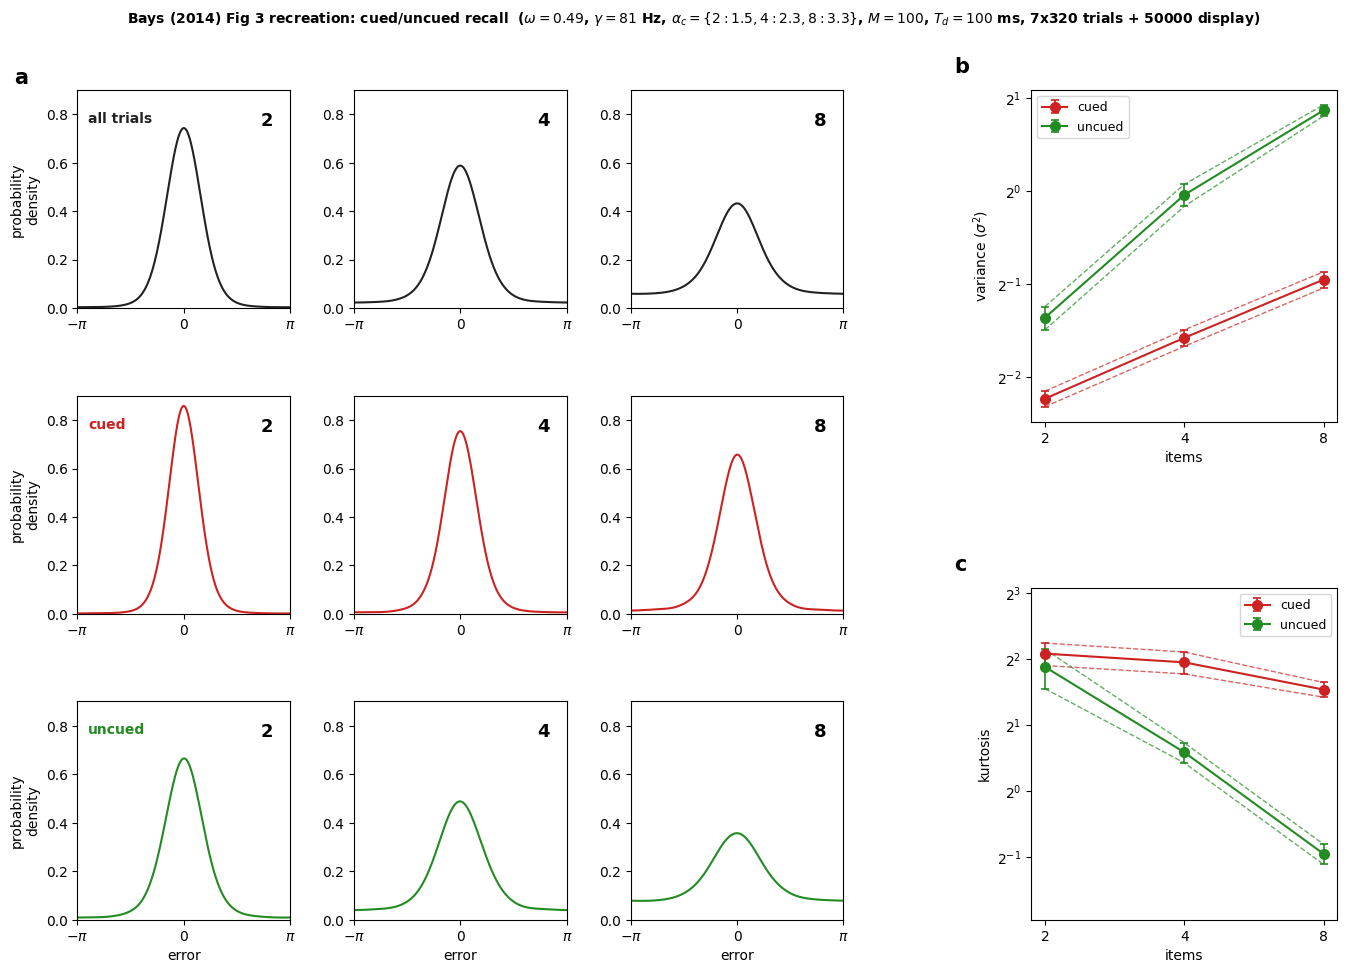

In [9]:
# Plot Bays Fig 3: panels a (3 rows x 3 cols), b (variance), c (kurtosis).

RED, GREEN, BLACK = '#CC2222', '#228B22', '#222222'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

# Per-row KDE bandwidth (cued is sharper -> needs a tighter kernel).
KAPPA_BY_ROW = {'err_all': 10.0, 'err_cued': 18.0, 'err_uncued': 10.0}

# Shared y-max for panel a (computed using each row's own bandwidth).
y_max = 0.0
for N in SET_SIZES:
    for k in ('err_all', 'err_cued', 'err_uncued'):
        d = vonmises_kde(summary_bays[N][k], theta_smooth, KAPPA_BY_ROW[k])
        y_max = max(y_max, float(d.max()))
y_max *= 1.05

fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.07, top=0.90)
gs_a  = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
            subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bc = gridspec.GridSpecFromSubplotSpec(2, 1,
            subplot_spec=outer[1], hspace=0.5)

# ---------- Panel a: 3 rows (all/cued/uncued) x 3 cols (l = 2, 4, 8) ----
row_configs = [('err_all',    BLACK, 'all trials'),
               ('err_cued',   RED,   'cued'),
               ('err_uncued', GREEN, 'uncued')]
first_ax = None
for row, (key, color, label) in enumerate(row_configs):
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        if first_ax is None:
            first_ax = ax
        d = vonmises_kde(summary_bays[N][key], theta_smooth,
                         KAPPA_BY_ROW[key])
        ax.plot(theta_smooth, d, color=color, lw=1.5)
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, y_max)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if row == 2:
            ax.set_xlabel('error')
        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='right')
        if col == 0:
            ax.set_ylabel('probability\ndensity')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top', color=color)

first_ax.text(-0.30, 1.10, r'$\mathbf{a}$', transform=first_ax.transAxes,
              fontsize=15, fontweight='bold', va='top')

ns = np.array(SET_SIZES, dtype=float)

def _plot_with_sem(ax, x, y, y_sem, color, label):
    # Solid line + dots with error bars (= empirical-style markers).
    ax.errorbar(x, y, yerr=y_sem, fmt='o-', color=color, lw=1.5,
                ms=7, capsize=3, capthick=1.2, elinewidth=1.2, label=label)
    # Dashed lines flanking the solid line at +/- 1 SEM (= Bays's dashed bands).
    y, y_sem = np.asarray(y), np.asarray(y_sem)
    ax.plot(x, y + y_sem, '--', color=color, lw=1.0, alpha=0.7)
    ax.plot(x, np.maximum(y - y_sem, 1e-6), '--', color=color, lw=1.0, alpha=0.7)

# ---------- Panel b: variance ----------
ax_b = fig.add_subplot(gs_bc[0])
vc      = [summary_bays[N]['vc']     for N in SET_SIZES]
vu      = [summary_bays[N]['vu']     for N in SET_SIZES]
vc_sem  = [summary_bays[N]['vc_sem'] for N in SET_SIZES]
vu_sem  = [summary_bays[N]['vu_sem'] for N in SET_SIZES]
_plot_with_sem(ax_b, ns, vc, vc_sem, RED,   'cued')
_plot_with_sem(ax_b, ns, vu, vu_sem, GREEN, 'uncued')
ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.legend(fontsize=9, loc='upper left')
ax_b.text(-0.25, 1.10, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel c: kurtosis ----------
ax_c = fig.add_subplot(gs_bc[1])
kc      = [summary_bays[N]['kc']     for N in SET_SIZES]
ku      = [summary_bays[N]['ku']     for N in SET_SIZES]
kc_sem  = [summary_bays[N]['kc_sem'] for N in SET_SIZES]
ku_sem  = [summary_bays[N]['ku_sem'] for N in SET_SIZES]
_plot_with_sem(ax_c, ns, kc, kc_sem, RED,   'cued')
_plot_with_sem(ax_c, ns, ku, ku_sem, GREEN, 'uncued')
ax_c.set_xscale('log', base=2); ax_c.set_yscale('log', base=2)
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])

all_k = [k for k in (kc + ku) if k > 0 and np.isfinite(k)]
if all_k:
    ax_c.set_ylim(min(all_k) * 0.5, max(all_k) * 2.0)
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.legend(fontsize=9, loc='upper right')
ax_c.text(-0.25, 1.10, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle(
    f"Bays (2014) Fig 3 recreation: cued/uncued recall  "
    f"($\\omega={OMEGA_B}$, $\\gamma={GAMMA_B:.0f}$ Hz, "
    f"$\\alpha_c=\\{{2{{:}}{ALPHA_CUED[2]}, 4{{:}}{ALPHA_CUED[4]}, 8{{:}}{ALPHA_CUED[8]}\\}}$, "
    f"$M={M_BAYS}$, $T_d={int(T_D_B*1000)}$ ms, "
    f"{N_BATCHES}x{N_TRIALS_PER_BATCH} trials + {N_TRIALS_DISPLAY} display)",
    fontsize=10, fontweight='bold')
plt.savefig(RESULTS_DIR / 'bays_fig3_recreation.png', dpi=150, bbox_inches='tight')
plt.show()


## Fitting our GP Framework to the Bays Model

We now have a working forward simulation of Bays's Experiment 2 (cells above). The next question is: **can our GP framework recover the parameters that generated those error distributions?** This is the cued/uncued analog of the parameter-recovery work we did in the Figure 2 notebook (Experiment 1) — but with an extra free parameter $\alpha_{\text{cued}}$ at each set size.

### What is "the data"?

Synthetic data generated by the Bays parametric model at known ground-truth parameters:
$\omega^* = 0.49,\; \gamma^* = 81$ Hz, and $\alpha^*_l \in \{1.5, 2.3, 3.3\}$ for $l \in \{2, 4, 8\}$ — the ML values Bays reports from human subjects in Fig 3d. This gives us a ground truth we can recover against.

Each set size produces three error pools — *cued*, *uncued*, and *all trials* (the 3:1 mixture):

- For $l = 2$: $p_{\text{cued}} = 0.75$, so 75% of trials are cued-probe.
- For $l = 4$: $p_{\text{cued}} = 0.50$, so 50/50.
- For $l = 8$: $p_{\text{cued}} = 0.30$, so 30% cued / 70% uncued.

**The "all trials" row is not an independent condition** — it is literally the union of the cued and uncued trials, mixed at the empirical ratio. We never fit against it directly; it falls out automatically once cued and uncued are fitted well, and serves only as a visual consistency check.

### Two-stage fit

Following the structure of Bays's own approach (Materials and Methods, p. 3634), we fit in two stages — first locking the **population physiology** (which describes the substrate and should be independent of cueing), then fitting the **attentional gain** that rides on top of it.

**Stage 1 — fit $(\lambda, \gamma, \text{CV})$ against uncued trials only.**
We treat the uncued-validity trials as our analog of Bays's Experiment 1 fit: a population at $\alpha_l = 1$ (no attentional boost on the probed location). The Stage 1 forward model itself uses $\alpha = 1$, so the fit identifies the static parameters of the substrate — tuning width $\lambda$, per-neuron gain $\gamma$, and lengthscale heterogeneity CV — without entanglement with the attentional mechanism. Output: locked $(\hat\lambda, \hat\gamma, \widehat{\text{CV}})$.

**Stage 2 — fit $\alpha_l$ (one number per set size) against cued + uncued errors at that set size.** With the physiology locked from Stage 1, the only remaining free parameter is the attentional gain. We run three independent 1-D fits, one per set size, each against the *joint* cued + uncued histogram at that $l$.

**Why joint cued + uncued, and not cued alone?**

> Because $\alpha$ controls both. Boosting $\alpha$ makes the cued > distribution sharper *and* makes the uncued distribution broader — > divisive normalization steals activity from uncued neurons via the > shared denominator. Both effects identify $\alpha$. If you fit > $\alpha$ to cued alone, you waste half the information; if you fit > to uncued alone, you waste the other half. The joint cued+uncued > residual is the right target.

This joint-residual logic is what makes Stage 2 well-conditioned with a single free parameter per set size: the cued and uncued distributions constrain $\alpha$ from opposite directions through the same DN coupling.

### Row × stage mapping

| Row (visualization) | Stage 1 input? | Stage 2 input? | Notes |
|---|---|---|---|
| Row 1 — *all trials* | No | No | Derived 3:1 mixture; falls out automatically as a consistency check. |
| Row 2 — *cued* | No | **Yes** (jointly with Row 3) | Used in Stage 2 only — identifies $\alpha_l$. |
| Row 3 — *uncued* | **Yes** (alone) | **Yes** (jointly with Row 2) | Used in *both* stages. Stage 1 fits physiology against uncued only; Stage 2 reuses uncued alongside cued to identify $\alpha$. |

The three rows are visualization slices, not separate fits. Row 1 ⊇ Row 2 ∪ Row 3 — they share trials.

### Optimality diagnostic — Bays's Fig 3d, no data needed

Once Stage 1 has given us locked $(\hat\lambda, \hat\gamma, \widehat{\text{CV}})$, we can ask a question that requires *no data at all*: what value of $\alpha_l$ would minimise the overall (3:1-weighted) error variance at this set size? That is the **optimality prediction** $\alpha^*_l$, computed by sweeping $\alpha$ over a log grid, running the forward model at each candidate, and finding the argmin of the total variance.

Bays's headline result (his Fig 3d) is that real human subjects' fitted $\hat\alpha_l$ track the optimality prediction $\alpha^*_l$ across set sizes — i.e. observers behave near-optimally. The GP analog of this claim is to show:

$$\alpha^*_l \text{ (no data)} \;\approx\; \hat\alpha_l \text{ (Stage 2 fit)} \;\approx\; \alpha^*_l \text{ (Bays ML truth)}$$

If the three agree, we've reproduced Bays's result inside our recruitment-based framework.

### Visualisation strategy — GP vs Bays

**Panel a** (the 3×3 grid of error distributions): each subplot overlays two KDEs — Bays generator solid, GP forward model dashed. Row colour stays as before (black / red / green); the dashing distinguishes Bays from GP. If Stage 1 and Stage 2 fits are good, the dashed traces should lie on top of the solid ones at every $(l, \text{validity})$.

**Panels b, c** (variance and kurtosis vs set size): two pairs of lines per panel — solid for Bays, dashed for GP, red for cued, green for uncued. SEM bands on both.

**Panel d** (the headline): three numbers per set size, side by side — Bays generator's truth $\alpha^*$ (ML from Fig 3d), our Stage 2 fitted $\hat\alpha$, and the optimality prediction $\alpha^*$ computed from Stage 1's locked physiology. Triple agreement is the headline result.

### Summary table — what's free, what's locked, what's fitted against what

| | **Stage 1** | **Stage 2** (one fit per $l$) | **Optimality sweep** |
|---|---|---|---|
| Free params | $\lambda,\;\gamma,\;\text{CV}$ | $\alpha_l$ (one number) | — (none; sweep $\alpha_l$) |
| Locked params | (none — all free) | $\hat\lambda,\;\hat\gamma,\;\widehat{\text{CV}}$ from Stage 1 | $\hat\lambda,\;\hat\gamma,\;\widehat{\text{CV}}$ from Stage 1 |
| Data fitted against | Uncued errors, all $l$ concatenated | Cued **and** uncued errors at one $l$ | None (compute prediction directly) |
| Output | $(\hat\lambda,\;\hat\gamma,\;\widehat{\text{CV}})$ | $\hat\alpha_l$, one per $l \in \{2, 4, 8\}$ | $\alpha^*_l = \arg\min$ variance, per $l$ |

### Robustness check (optional, after both stages)

Bays himself ran a joint fit of all five parameters in his Exp 2 and compared the resulting $(\hat\omega, \hat\gamma)$ to his Exp 1 values — a t-test for parameter migration between the two tasks. We can do the equivalent here: run *one* joint 4-parameter fit $(\lambda, \gamma, \text{CV}, \alpha_l)$ as a sanity check, and verify the $(\lambda, \gamma, \text{CV})$ estimates match the Stage 1 values. Agreement validates the two-stage decomposition; disagreement is diagnostically interesting in its own right.


In [13]:
# ============================================================
# Phase 2 setup: synthetic Bays data + residual vectors + GP forward
# ============================================================
# UNIFIED API: this notebook now uses Population.run_trials() as the single
# source of truth for the GP trial engine, with new keyword arguments:
#   - active_locations: deterministic location ordering
#   - probe_cued:       True/False/None for cued/uncued/auto sampling
#   - alpha:            recruitment multiplier
#   - recruited_mask:   which neurons get boosted
#
# This matches Figure 2's API (modulo the new attention args), so any
# changes to the trial engine propagate to both notebooks automatically.

from scipy.optimize import least_squares

# ---- Ground truth (Bays ML values from Fig 3d) ----
OMEGA_GEN_BAYS    = 0.49
GAMMA_TOTAL_GEN_B = 81.0
ALPHA_GEN_BAYS    = {2: 1.5, 4: 2.3, 8: 3.3}
M_BAYS_FIT        = M

# ---- Fit configuration ----
SEED_FIT     = 42
N_DATA       = 10_000     # trials per set size for Bays synthetic data
N_TRIALS_FIT = 3_000      # trials per validity in GP forward model
N_BINS       = 50
BIN_EDGES    = np.linspace(-np.pi, np.pi, N_BINS + 1)

# ---- GP sampler: Gamma (matches Figure 2's Gamma-sampler fits) ----
GP_METHOD = 'gamma'

print(f'Ground truth: omega*={OMEGA_GEN_BAYS}, '
      f'gamma_total*={GAMMA_TOTAL_GEN_B} Hz, '
      f'alpha*={ALPHA_GEN_BAYS}')
print(f'GP forward: {N_TRIALS_FIT} trials per validity, '
      f'{N_BINS} histogram bins, sampler={GP_METHOD}')


# ============================================================
# Step 1: Generate Bays cued/uncued synthetic data
# ============================================================
print('\nGenerating Bays cued/uncued synthetic data...')
bays_data = {}
rng_data = np.random.RandomState(SEED_FIT)

for N in SET_SIZES:
    err_all, is_cued = bays_run_trials_cued(
        n_trials=N_DATA, set_size=N,
        omega=OMEGA_GEN_BAYS, gamma_total=GAMMA_TOTAL_GEN_B,
        T_d=T_D, alpha_cued=ALPHA_GEN_BAYS[N],
        cued_probe_ratio=CUE_RATIO,
        M_bays=M_BAYS_FIT, rng=rng_data,
    )
    err_c, err_u = err_all[is_cued], err_all[~is_cued]
    h_c, _ = np.histogram(err_c, bins=BIN_EDGES, density=True)
    h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
    bays_data[N] = dict(
        err_cued=err_c, err_uncued=err_u,
        hist_cued=h_c,  hist_uncued=h_u,
    )
    print(f'  l={N}: n_cued={len(err_c)}, n_uncued={len(err_u)}, '
          f'var_c={_circ_var(err_c):.3f}, var_u={_circ_var(err_u):.3f}')


# ============================================================
# Step 2: Build residual targets
# ============================================================
data_vector_stage1 = np.concatenate([
    bays_data[N]['hist_uncued'] for N in SET_SIZES
])

data_vector_stage2 = {
    N: np.concatenate([bays_data[N]['hist_cued'],
                       bays_data[N]['hist_uncued']])
    for N in SET_SIZES
}

print(f'\nStage 1 residual length: {len(data_vector_stage1)} '
      f'(= {len(SET_SIZES)} set sizes x {N_BINS} bins)')
print(f'Stage 2 residual length per l: '
      f'{len(data_vector_stage2[SET_SIZES[0]])} '
      f'(= 2 validities x {N_BINS} bins)')


# ============================================================
# Step 3: GP forward-model helper — now uses Population.run_trials
# ============================================================
def gp_forward(lambda_base, gamma_per_neuron, cv, alpha, set_size,
               n_trials, seed=0):
    """Run the GP forward model via Population.run_trials.

    Returns (err_cued, err_uncued), each of length n_trials. Both
    validities come out of the SAME population (same seed) — only the
    probe location differs.
    """
    omega_local = lambda_base ** 2
    pop_local = Population(
        M=M, n_theta=N_THETA, omega=omega_local,
        tuning_type='gp', n_locations=max(SET_SIZES), seed=seed,
        lengthscale_variability=cv, gain_variability=0.0,
        method=GP_METHOD,
    )

    # Recruitment mask: top M/l sharpest-tuned-at-loc-0 neurons.
    sharpness = pop_local.f[:, 0, :].var(axis=1)
    M_recruit = M // set_size
    recruited_mask = np.zeros(M, dtype=bool)
    recruited_mask[np.argsort(-sharpness)[:M_recruit]] = True

    # Active locations: deterministic ordering 0, 1, ..., set_size - 1.
    active = tuple(range(set_size))

    err_c = pop_local.run_trials(
        n_trials=n_trials, gamma=gamma_per_neuron, T_d=T_D,
        set_size=set_size, sigma_sq=SIGMA_SQ,
        rng=np.random.RandomState(seed + set_size * 1000),
        active_locations=active, probe_cued=True,
        alpha=alpha, recruited_mask=recruited_mask,
    )
    err_u = pop_local.run_trials(
        n_trials=n_trials, gamma=gamma_per_neuron, T_d=T_D,
        set_size=set_size, sigma_sq=SIGMA_SQ,
        rng=np.random.RandomState(seed + set_size * 1000 + 500_000),
        active_locations=active,
        probe_cued=(False if set_size > 1 else None),
        alpha=alpha, recruited_mask=recruited_mask,
    )
    return err_c, err_u


print('\nDefined: gp_forward(lambda, gamma, cv, alpha, set_size, n_trials, seed)')
print('         (uses Population.run_trials via the unified API)')


Ground truth: omega*=0.49, gamma_total*=81.0 Hz, alpha*={2: 1.5, 4: 2.3, 8: 3.3}
GP forward: 3000 trials per validity, 50 histogram bins, sampler=gamma

Generating Bays cued/uncued synthetic data...
  l=2: n_cued=7553, n_uncued=2447, var_c=0.227, var_u=0.401
  l=4: n_cued=5058, n_uncued=4942, var_c=0.358, var_u=0.997
  l=8: n_cued=3006, n_uncued=6994, var_c=0.567, var_u=1.891

Stage 1 residual length: 150 (= 3 set sizes x 50 bins)
Stage 2 residual length per l: 100 (= 2 validities x 50 bins)

Defined: gp_forward(lambda, gamma, cv, alpha, set_size, n_trials, seed)
         (uses Population.run_trials via the unified API)


### Stage 1 — Fitting Population Physiology to Uncued Trials

Free parameters: $\lambda, \gamma, \text{CV}$. Forward model runs with $\alpha = 1$ (no attentional gain) and we fit against the *uncued-probe* errors only, concatenated across all three set sizes. Output: locked $(\hat\lambda, \hat\gamma, \widehat{\text{CV}})$ that will be reused in Stage 2 and in the optimality sweep.


In [16]:
# === STAGE 1: fit (lambda, gamma, CV) against UNCUED errors only ===
# Cache-aware: skips the 40-minute fit when a matching result is on disk.
# Cache key encodes ground-truth + fit-config + sampler, so any meaningful
# change forces a refit; pure plotting changes leave the cache valid.

from tqdm.auto import tqdm
import hashlib, json as _json

X0_STAGE1 = [1.0,  0.5,   0.5]    # was [1.0, 2.0, 0.5]
LO_STAGE1 = [0.2,  0.01,  0.05]   # was [0.2, 0.2, 0.05]
HI_STAGE1 = [2.0,  2.0,   3.0]    # was [2.0, 8.0, 3.0]
DIFF_STEP_STAGE1 = 0.05
_PENALTY_VALUE = 100.0

# ---- Cache key ----
_cache_key_dict = {
    'omega_gen':       OMEGA_GEN_BAYS,
    'gamma_total_gen': GAMMA_TOTAL_GEN_B,
    'alpha_gen':       ALPHA_GEN_BAYS,
    'M_bays':          M_BAYS_FIT,
    'N_data':          N_DATA,
    'cue_ratio':       CUE_RATIO,
    'T_d':             T_D,
    'M_gp':            M,
    'N_theta_gp':      N_THETA,
    'N_trials_fit':    N_TRIALS_FIT,
    'sigma_sq':        SIGMA_SQ,
    'set_sizes':       SET_SIZES,
    'seed_fit':        SEED_FIT,
    'gp_method':       GP_METHOD,
    'x0_stage1':       X0_STAGE1,
    'lo_stage1':       LO_STAGE1,
    'hi_stage1':       HI_STAGE1,
    'diff_step':       DIFF_STEP_STAGE1,
    'n_bins':          N_BINS,
    'penalty':         _PENALTY_VALUE,
    'stage':           'stage1_unified_api_v1',
}
_cache_key = hashlib.md5(
    _json.dumps(_cache_key_dict, sort_keys=True, default=str).encode()
).hexdigest()[:12]

CACHE_DIR  = RESULTS_DIR / 'fit_cache'
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / f'stage1_{_cache_key}.npz'

FORCE_REFIT_STAGE1 = False   # set True to bypass cache

if CACHE_FILE.exists() and not FORCE_REFIT_STAGE1:
    print(f'Stage 1 cache HIT: loading {CACHE_FILE.name}')
    cached = np.load(CACHE_FILE, allow_pickle=True)
    LAMBDA_LOCKED = float(cached['lambda_hat'])
    GAMMA_LOCKED  = float(cached['gamma_hat'])
    CV_LOCKED     = float(cached['cv_hat'])
    lambda_hat, gamma_hat, cv_hat = LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED
    omega_hat       = float(cached['omega_hat'])
    gamma_total_hat = float(cached['gamma_total_hat'])
    print(f'  Loaded: lambda={LAMBDA_LOCKED:.4f}, gamma={GAMMA_LOCKED:.4f}, '
          f'CV={CV_LOCKED:.4f}')
    print(f'  Cached cost: {float(cached["final_cost"]):.6f}, '
          f'evals: {int(cached["total_evals"])}, '
          f'failures: {int(cached["failures"])}')

else:
    if FORCE_REFIT_STAGE1:
        print('FORCE_REFIT_STAGE1 = True: refitting...')
    else:
        print(f'Stage 1 cache MISS (key {_cache_key}): running fit...')

    def forward_stage1(lambda_base, gamma_per_neuron, cv, seed=SEED_FIT):
        pred_hists = []
        try:
            for N in SET_SIZES:
                _, err_u = gp_forward(
                    lambda_base, gamma_per_neuron, cv,
                    alpha=1.0, set_size=N,
                    n_trials=N_TRIALS_FIT, seed=seed,
                )
                h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
                pred_hists.append(h_u)
            return np.concatenate(pred_hists)
        except (np.linalg.LinAlgError, ValueError):
            return None

    _pbar = tqdm(desc='Stage 1 (lambda, gamma, CV)', unit='eval')
    _call_log = {'best_cost': np.inf, 'best_params': None, 'failures': 0}

    def residual_stage1(params):
        lam, gam, cv = params
        pred = forward_stage1(lam, gam, cv)
        if pred is None:
            _call_log['failures'] += 1
            res = np.full_like(data_vector_stage1, _PENALTY_VALUE)
            cost = 0.5 * float(np.sum(res ** 2))
        else:
            res = data_vector_stage1 - pred
            cost = 0.5 * float(np.sum(res ** 2))
            if cost < _call_log['best_cost']:
                _call_log['best_cost']   = cost
                _call_log['best_params'] = (lam, gam, cv)
        _pbar.update(1)
        _pbar.set_postfix(
            lam=f'{lam:.3f}', gam=f'{gam:.3f}', cv=f'{cv:.3f}',
            cost=f'{cost:.2f}', best=f'{_call_log["best_cost"]:.4f}',
            fails=_call_log['failures'],
        )
        return res

    print(f'Parameter bounds: lambda in [{LO_STAGE1[0]}, {HI_STAGE1[0]}], '
          f'gamma in [{LO_STAGE1[1]}, {HI_STAGE1[1]}], '
          f'CV in [{LO_STAGE1[2]}, {HI_STAGE1[2]}]')
    t0 = time.time()
    result_stage1 = least_squares(
        residual_stage1, x0=X0_STAGE1,
        bounds=(LO_STAGE1, HI_STAGE1),
        method='trf', diff_step=DIFF_STEP_STAGE1, verbose=0,
        max_nfev=200,
    )
    _pbar.close()

    lambda_hat, gamma_hat, cv_hat = result_stage1.x
    omega_hat       = lambda_hat ** 2
    gamma_total_hat = gamma_hat * M
    LAMBDA_LOCKED = lambda_hat
    GAMMA_LOCKED  = gamma_hat
    CV_LOCKED     = cv_hat

    # SAVE TO CACHE -- this MUST happen before the kernel restarts!
    np.savez(
        CACHE_FILE,
        lambda_hat=LAMBDA_LOCKED, gamma_hat=GAMMA_LOCKED, cv_hat=CV_LOCKED,
        omega_hat=omega_hat, gamma_total_hat=gamma_total_hat,
        final_cost=result_stage1.cost, total_evals=_pbar.n,
        failures=_call_log['failures'],
        cache_key_dict=_json.dumps(_cache_key_dict, sort_keys=True, default=str),
    )
    print(f'\nStage 1 cache SAVED: {CACHE_FILE.name}')

# ---- Print summary regardless ----
print(f'\n=== Stage 1 results ===')
print(f'  lambda_hat  = {lambda_hat:.4f}  '
      f'(omega_hat = {omega_hat:.4f},  Bays generating omega = {OMEGA_GEN_BAYS})')
print(f'  gamma_hat   = {gamma_hat:.4f}  '
      f'(gamma_total = {gamma_total_hat:.1f} Hz,  '
      f'Bays generating gamma_total = {GAMMA_TOTAL_GEN_B})')
print(f'  CV_hat      = {cv_hat:.4f}')
print(f'\nLocked for Stage 2: lambda={LAMBDA_LOCKED:.4f}, '
      f'gamma={GAMMA_LOCKED:.4f}, CV={CV_LOCKED:.4f}')


Stage 1 cache MISS (key 6f1a5c11cae7): running fit...


Stage 1 (lambda, gamma, CV): 0eval [00:00, ?eval/s]

Parameter bounds: lambda in [0.2, 2.0], gamma in [0.01, 2.0], CV in [0.05, 3.0]

Stage 1 cache SAVED: stage1_6f1a5c11cae7.npz

=== Stage 1 results ===
  lambda_hat  = 1.8696  (omega_hat = 3.4955,  Bays generating omega = 0.49)
  gamma_hat   = 0.2921  (gamma_total = 292.1 Hz,  Bays generating gamma_total = 81.0)
  CV_hat      = 0.5271

Locked for Stage 2: lambda=1.8696, gamma=0.2921, CV=0.5271


### Stage 2 — Fitting Attentional Gain $\alpha_l$ per Set Size

Locked: $(\hat\lambda, \hat\gamma, \widehat{\text{CV}})$ from Stage 1. Free: $\alpha_l$, one number per set size. Three independent 1-D fits, each minimising the residual against the *joint cued + uncued* histogram at that set size. Output: $\hat\alpha_2, \hat\alpha_4, \hat\alpha_8$ for comparison against the Bays ML truth and the optimality prediction.


In [17]:
# === STAGE 2: fit alpha_l per set size at LOCKED (lambda, gamma, CV) ===
# Cache-aware: a single .npz holds all three alpha fits.

import hashlib, json as _json

X0_STAGE2 = [3.0]
LO_STAGE2 = [1.0]
HI_STAGE2 = [30.0]
DIFF_STEP_STAGE2 = 0.1

_cache_key_dict_s2 = {
    'lambda_locked': LAMBDA_LOCKED,
    'gamma_locked':  GAMMA_LOCKED,
    'cv_locked':     CV_LOCKED,
    'alpha_gen':     ALPHA_GEN_BAYS,
    'set_sizes':     SET_SIZES,
    'N_trials_fit':  N_TRIALS_FIT,
    'seed_fit':      SEED_FIT,
    'gp_method':     GP_METHOD,
    'x0_stage2':     X0_STAGE2,
    'lo_stage2':     LO_STAGE2,
    'hi_stage2':     HI_STAGE2,
    'diff_step':     DIFF_STEP_STAGE2,
    'stage':         'stage2_unified_api_v1',
}
_cache_key_s2 = hashlib.md5(
    _json.dumps(_cache_key_dict_s2, sort_keys=True, default=str).encode()
).hexdigest()[:12]
CACHE_FILE_S2 = CACHE_DIR / f'stage2_{_cache_key_s2}.npz'

FORCE_REFIT_STAGE2 = False

if CACHE_FILE_S2.exists() and not FORCE_REFIT_STAGE2:
    print(f'Stage 2 cache HIT: loading {CACHE_FILE_S2.name}')
    cached = np.load(CACHE_FILE_S2, allow_pickle=True)
    stage2_results = {}
    for N in SET_SIZES:
        stage2_results[N] = dict(
            alpha_hat  = float(cached[f'alpha_hat_{N}']),
            alpha_true = ALPHA_GEN_BAYS[N],
            cost       = float(cached[f'cost_{N}']),
        )
        print(f'  l={N}: alpha_hat={stage2_results[N]["alpha_hat"]:.3f} '
              f'(truth={ALPHA_GEN_BAYS[N]})')

else:
    print(f'Stage 2 cache MISS (key {_cache_key_s2}): running 3 fits...')

    def forward_stage2(alpha, set_size, seed=SEED_FIT):
        err_c, err_u = gp_forward(
            LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED,
            alpha=alpha, set_size=set_size,
            n_trials=N_TRIALS_FIT, seed=seed,
        )
        h_c, _ = np.histogram(err_c, bins=BIN_EDGES, density=True)
        h_u, _ = np.histogram(err_u, bins=BIN_EDGES, density=True)
        return np.concatenate([h_c, h_u])

    def make_residual_stage2(set_size):
        def residual(params):
            alpha = params[0]
            return data_vector_stage2[set_size] - forward_stage2(alpha, set_size)
        return residual

    print(f'Stage 2: locked lambda={LAMBDA_LOCKED:.4f}, '
          f'gamma={GAMMA_LOCKED:.4f}, CV={CV_LOCKED:.4f}\n')

    stage2_results = {}
    save_kwargs = {}
    for N in SET_SIZES:
        print(f'--- l = {N}  (Bays truth alpha = {ALPHA_GEN_BAYS[N]}) ---')
        t0 = time.time()
        result = least_squares(
            make_residual_stage2(N),
            x0=X0_STAGE2, bounds=(LO_STAGE2, HI_STAGE2),
            method='trf', diff_step=DIFF_STEP_STAGE2, verbose=0,
        )
        alpha_hat = float(result.x[0])
        stage2_results[N] = dict(
            alpha_hat  = alpha_hat,
            alpha_true = ALPHA_GEN_BAYS[N],
            cost       = result.cost,
        )
        save_kwargs[f'alpha_hat_{N}'] = alpha_hat
        save_kwargs[f'cost_{N}']      = result.cost
        print(f'  alpha_hat = {alpha_hat:.3f}  '
              f'(truth = {ALPHA_GEN_BAYS[N]}, abs error = '
              f'{abs(alpha_hat - ALPHA_GEN_BAYS[N]):.3f})')
        print(f'  cost = {result.cost:.4f}, time = {time.time()-t0:.1f}s')

    np.savez(
        CACHE_FILE_S2,
        cache_key_dict=_json.dumps(_cache_key_dict_s2, sort_keys=True, default=str),
        **save_kwargs,
    )
    print(f'\nStage 2 cache SAVED: {CACHE_FILE_S2.name}')

print('\n=== Stage 2 summary ===')
print(f'{"l":>3}  {"alpha_true":>11}  {"alpha_hat":>10}  '
      f'{"abs_err":>8}  {"cost":>8}')
for N in SET_SIZES:
    r = stage2_results[N]
    err = abs(r['alpha_hat'] - r['alpha_true'])
    print(f'{N:>3}  {r["alpha_true"]:>11.3f}  {r["alpha_hat"]:>10.3f}  '
          f'{err:>8.3f}  {r["cost"]:>8.4f}')


Stage 2 cache MISS (key 236f91a5bd73): running 3 fits...
Stage 2: locked lambda=1.8696, gamma=0.2921, CV=0.5271

--- l = 2  (Bays truth alpha = 1.5) ---


  alpha_hat = 3.647  (truth = 1.5, abs error = 2.147)
  cost = 2.5570, time = 345.1s
--- l = 4  (Bays truth alpha = 2.3) ---
  alpha_hat = 3.347  (truth = 2.3, abs error = 1.047)
  cost = 1.7554, time = 333.2s
--- l = 8  (Bays truth alpha = 3.3) ---
  alpha_hat = 2.996  (truth = 3.3, abs error = 0.304)
  cost = 0.9935, time = 280.7s

Stage 2 cache SAVED: stage2_236f91a5bd73.npz

=== Stage 2 summary ===
  l   alpha_true   alpha_hat   abs_err      cost
  2        1.500       3.647     2.147    2.5570
  4        2.300       3.347     1.047    1.7554
  8        3.300       2.996     0.304    0.9935


### Bays vs GP overlay — the headline comparison

Generates GP forward predictions at the locked physiology plus fitted α_l (one per set size), then overlays them on the Bays generator's ground-truth curves.

- Bays = dashed, GP = solid (same line style in all panels).
- Cued = red, uncued = green, all trials = black.
- Panel d (the optimality bar chart) is not included here — that's the next step.


Generating GP forward predictions at fitted parameters...
  l=2: alpha=3.647, var_c=0.074, var_u=0.145
  l=4: alpha=3.347, var_c=0.141, var_u=0.246
  l=8: alpha=2.996, var_c=0.522, var_u=0.516
Panel a peak=1.22, ymax=1.65, ticks=[0, 0.5, 1.0, 1.5]

Saved figure to /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data/bays_fig3_gp_overlay.png


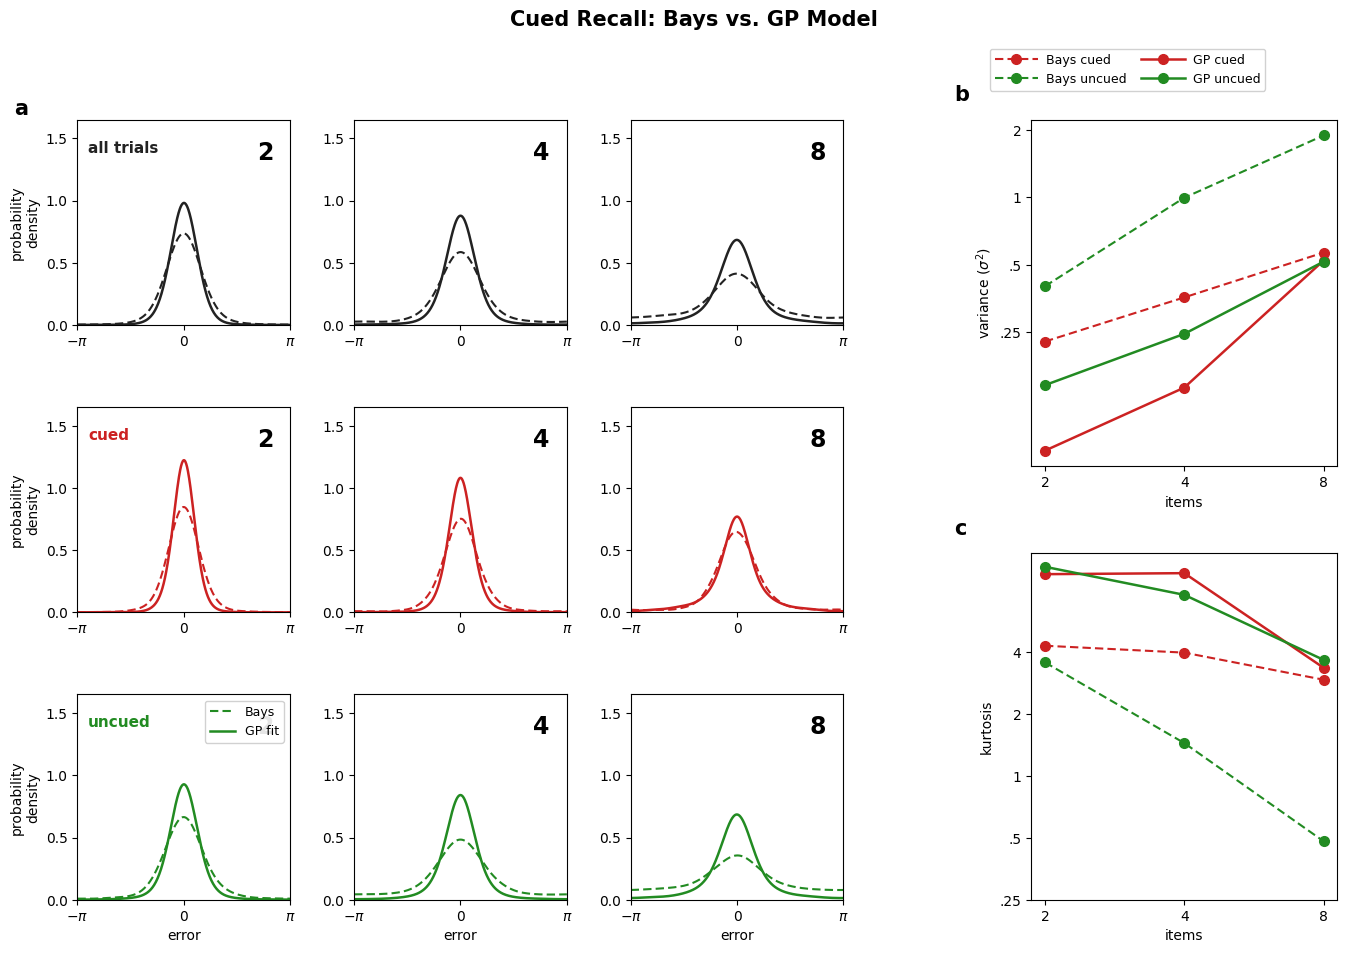

In [18]:
# === Plot Bays vs GP overlay (the headline comparison figure) ===
# Cued = red, uncued = green, all trials = black.
# Bays = dashed, GP = solid.

from pathlib import Path

# ---- 1. Generate the GP "fit" curves at the fitted parameters ----
print('Generating GP forward predictions at fitted parameters...')
gp_predictions = {}
for N in SET_SIZES:
    err_c, err_u = gp_forward(
        LAMBDA_LOCKED, GAMMA_LOCKED, CV_LOCKED,
        alpha=stage2_results[N]['alpha_hat'],
        set_size=N,
        n_trials=N_TRIALS_FIT * 3,
        seed=SEED_FIT,
    )
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    n_c = int(round(p_c * len(err_c)))
    n_u = len(err_c) - n_c
    err_a = np.concatenate([err_c[:n_c], err_u[:n_u]])
    gp_predictions[N] = dict(
        err_all=err_a, err_cued=err_c, err_uncued=err_u,
        vc=circular_variance_fisher(err_c),
        vu=circular_variance_fisher(err_u),
        kc=circular_kurtosis_fisher(err_c),
        ku=circular_kurtosis_fisher(err_u),
    )
    print(f'  l={N}: alpha={stage2_results[N]["alpha_hat"]:.3f}, '
          f'var_c={gp_predictions[N]["vc"]:.3f}, '
          f'var_u={gp_predictions[N]["vu"]:.3f}')

# ---- 2. Plot ----
RED, GREEN, BLACK = '#CC2222', '#228B22', '#222222'
ROW_COLOR = {'err_all': BLACK, 'err_cued': RED, 'err_uncued': GREEN}

theta_smooth = np.linspace(-np.pi, np.pi, 500)
KAPPA_BY_ROW = {'err_all': 10.0, 'err_cued': 18.0, 'err_uncued': 10.0}

# Build 'err_all' for Bays (mixture at empirical 3:1 ratio).
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    n_c = int(round(p_c * len(bays_data[N]['err_cued'])))
    n_u = len(bays_data[N]['err_cued']) - n_c
    bays_data[N]['err_all'] = np.concatenate([
        bays_data[N]['err_cued'][:n_c],
        bays_data[N]['err_uncued'][:n_u],
    ])

# Compute panel-a y-max from actual KDE peaks across both models.
peak = 0.0
for N in SET_SIZES:
    for k in ('err_all', 'err_cued', 'err_uncued'):
        for src in (bays_data[N], gp_predictions[N]):
            d = vonmises_kde(src[k], theta_smooth, KAPPA_BY_ROW[k])
            peak = max(peak, float(d.max()))

if   peak <= 1.10: PANEL_A_YMAX, PANEL_A_YTICKS = 1.10, [0, 0.5, 1.0]
elif peak <= 1.65: PANEL_A_YMAX, PANEL_A_YTICKS = 1.65, [0, 0.5, 1.0, 1.5]
elif peak <= 2.20: PANEL_A_YMAX, PANEL_A_YTICKS = 2.20, [0, 0.5, 1.0, 1.5, 2.0]
elif peak <= 3.30: PANEL_A_YMAX, PANEL_A_YTICKS = 3.30, [0, 1.0, 2.0, 3.0]
else:              PANEL_A_YMAX, PANEL_A_YTICKS = peak * 1.10, None
print(f'Panel a peak={peak:.2f}, ymax={PANEL_A_YMAX:.2f}, ticks={PANEL_A_YTICKS}')

fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.08, top=0.86)
gs_a  = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
            subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bc = gridspec.GridSpecFromSubplotSpec(2, 1,
            subplot_spec=outer[1], hspace=0.25)

# ---------- Panel a ----------
row_configs = [('err_all',    'all trials'),
               ('err_cued',   'cued'),
               ('err_uncued', 'uncued')]

first_ax = None
panel_a_legend_handles = None
for row, (key, label) in enumerate(row_configs):
    color = ROW_COLOR[key]
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        if first_ax is None: first_ax = ax

        d_bays = vonmises_kde(bays_data[N][key],     theta_smooth, KAPPA_BY_ROW[key])
        d_gp   = vonmises_kde(gp_predictions[N][key], theta_smooth, KAPPA_BY_ROW[key])
        h_bays, = ax.plot(theta_smooth, d_bays, color=color, lw=1.5,
                          ls='--', dashes=(4, 2), label='Bays')
        h_gp,   = ax.plot(theta_smooth, d_gp,   color=color, lw=1.8,
                          ls='-', label='GP fit')

        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, PANEL_A_YMAX)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if PANEL_A_YTICKS is not None:
            ax.set_yticks(PANEL_A_YTICKS)
        if row == 2: ax.set_xlabel('error')

        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=17, fontweight='bold', va='top', ha='right')

        if col == 0:
            ax.set_ylabel('probability\ndensity')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=11, fontweight='bold', va='top', color=color)

        if row == 2 and col == 0:
            panel_a_legend_handles = (h_bays, h_gp)

fig.axes[-len(SET_SIZES)].legend(panel_a_legend_handles, ['Bays', 'GP fit'],
                                  fontsize=9, loc='upper right',
                                  frameon=True, framealpha=0.9)

first_ax.text(-0.30, 1.10, r'$\mathbf{a}$', transform=first_ax.transAxes,
              fontsize=15, fontweight='bold', va='top')

ns = np.array(SET_SIZES, dtype=float)

# ---------- Panel b: variance ----------
ax_b = fig.add_subplot(gs_bc[0])
vc_bays = [circular_variance_fisher(bays_data[N]['err_cued'])   for N in SET_SIZES]
vu_bays = [circular_variance_fisher(bays_data[N]['err_uncued']) for N in SET_SIZES]
vc_gp   = [gp_predictions[N]['vc'] for N in SET_SIZES]
vu_gp   = [gp_predictions[N]['vu'] for N in SET_SIZES]

l_bays_c, = ax_b.plot(ns, vc_bays, 'o', color=RED,   lw=1.5, ms=7,
                      ls='--', dashes=(4, 2), label='Bays cued')
l_bays_u, = ax_b.plot(ns, vu_bays, 'o', color=GREEN, lw=1.5, ms=7,
                      ls='--', dashes=(4, 2), label='Bays uncued')
l_gp_c,   = ax_b.plot(ns, vc_gp,   'o-',  color=RED,   lw=1.8, ms=7,
                      label='GP cued')
l_gp_u,   = ax_b.plot(ns, vu_gp,   'o-',  color=GREEN, lw=1.8, ms=7,
                      label='GP uncued')

ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_yticks([0.25, 0.5, 1.0, 2.0])
ax_b.set_yticklabels(['.25', '.5', '1', '2'])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.text(-0.25, 1.10, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel c: kurtosis ----------
ax_c = fig.add_subplot(gs_bc[1])
kc_bays = [circular_kurtosis_fisher(bays_data[N]['err_cued'])   for N in SET_SIZES]
ku_bays = [circular_kurtosis_fisher(bays_data[N]['err_uncued']) for N in SET_SIZES]
kc_gp   = [gp_predictions[N]['kc'] for N in SET_SIZES]
ku_gp   = [gp_predictions[N]['ku'] for N in SET_SIZES]

ax_c.plot(ns, kc_bays, 'o', color=RED,   lw=1.5, ms=7, ls='--', dashes=(4, 2))
ax_c.plot(ns, ku_bays, 'o', color=GREEN, lw=1.5, ms=7, ls='--', dashes=(4, 2))
ax_c.plot(ns, kc_gp,   'o-', color=RED,   lw=1.8, ms=7)
ax_c.plot(ns, ku_gp,   'o-', color=GREEN, lw=1.8, ms=7)

ax_c.set_xscale('log', base=2); ax_c.set_yscale('log', base=2)
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])
ax_c.set_yticks([0.25, 0.5, 1.0, 2.0, 4.0])
ax_c.set_yticklabels(['.25', '.5', '1', '2', '4'])
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.text(-0.25, 1.10, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

# Shared legend for b and c, above the column.
fig.legend(handles=[l_bays_c, l_bays_u, l_gp_c, l_gp_u],
           loc='center', bbox_to_anchor=(0.81, 0.91),
           fontsize=9, frameon=True, framealpha=0.9,
           ncol=2, columnspacing=1.2, handlelength=3.5, handletextpad=0.6)

fig.suptitle('Cued Recall: Bays vs. GP Model',
             fontsize=15, fontweight='bold', y=0.97)

out_path = RESULTS_DIR / 'bays_fig3_gp_overlay.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'\nSaved figure to {out_path}')
plt.show()
